# coffee_quality_prediction

In [246]:
import kagglehub
path = kagglehub.dataset_download("fatihb/coffee-quality-data-cqi")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\paton\.cache\kagglehub\datasets\fatihb\coffee-quality-data-cqi\versions\1


### Load Dataset
The dataset import to a pandas DataFrame to analysis.

In [248]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [251]:
data = pd.read_csv(r'C:\Users\paton\.cache\kagglehub\datasets\fatihb\coffee-quality-data-cqi\versions\1\df_arabica_clean.csv')
data.head()

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


### Data Overview
Exploration of dataset including the number of rows, columns, and data types.

In [254]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    object 
 3   Farm Name              205 non-null    object 
 4   Lot Number             206 non-null    object 
 5   Mill                   204 non-null    object 
 6   ICO Number             75 non-null     object 
 7   Company                207 non-null    object 
 8   Altitude               206 non-null    object 
 9   Region                 205 non-null    object 
 10  Producer               206 non-null    object 
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    object 
 13  In-Country Partner     207 non-null    object 
 14  Harvest Year           207 non-null    object 
 15  Gradin

In [256]:
data.shape

(207, 41)

### Missing Value 
Exploration of dataset for missing values and cleaned to obtain a clean dataset for further analysis.

In [259]:
data.isnull().sum()

Unnamed: 0                 0
ID                         0
Country of Origin          0
Farm Name                  2
Lot Number                 1
Mill                       3
ICO Number               132
Company                    0
Altitude                   1
Region                     2
Producer                   1
Number of Bags             0
Bag Weight                 0
In-Country Partner         0
Harvest Year               0
Grading Date               0
Owner                      0
Variety                    6
Status                     0
Processing Method          5
Aroma                      0
Flavor                     0
Aftertaste                 0
Acidity                    0
Body                       0
Balance                    0
Uniformity                 0
Clean Cup                  0
Sweetness                  0
Overall                    0
Defects                    0
Total Cup Points           0
Moisture Percentage        0
Category One Defects       0
Quakers       

In [261]:
data = data.dropna()
data.isnull().sum()

Unnamed: 0               0
ID                       0
Country of Origin        0
Farm Name                0
Lot Number               0
Mill                     0
ICO Number               0
Company                  0
Altitude                 0
Region                   0
Producer                 0
Number of Bags           0
Bag Weight               0
In-Country Partner       0
Harvest Year             0
Grading Date             0
Owner                    0
Variety                  0
Status                   0
Processing Method        0
Aroma                    0
Flavor                   0
Aftertaste               0
Acidity                  0
Body                     0
Balance                  0
Uniformity               0
Clean Cup                0
Sweetness                0
Overall                  0
Defects                  0
Total Cup Points         0
Moisture Percentage      0
Category One Defects     0
Quakers                  0
Color                    0
Category Two Defects     0
E

### Duplicate Data
Check duplicate data and remove.

In [264]:
data.duplicated().sum()

0

### Exploratory Data Analysis

- Exploration the distribution of target variable `total_cup_points`.

<Axes: xlabel='Total Cup Points', ylabel='Count'>

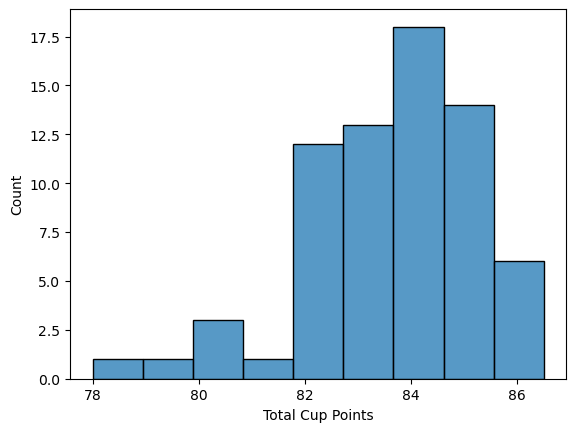

In [268]:
sns.histplot(data['Total Cup Points'])

- Correlation Analysis


 : Visualization of correlation between numberic feature to explore which attributes are strongly related to coffee quality.

In [272]:
numberic_data = data.select_dtypes(include='number').drop(columns=['Unnamed: 0','ID'])
numberic_data


,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
9,320,8.08,8.17,8.08,8.17,8.00,8.00,10.0,10.0,10.0,8.00,0.0,86.50,11.0,0,0,0
10,10,8.08,8.25,8.00,8.08,7.92,7.92,10.0,10.0,10.0,8.00,0.0,86.25,11.8,0,1,1
13,40,7.67,8.17,8.00,8.33,8.00,8.00,10.0,10.0,10.0,8.00,0.0,86.17,11.6,0,3,2
17,5,8.00,8.17,8.00,7.92,7.92,7.92,10.0,10.0,10.0,8.17,0.0,86.08,10.3,0,0,0
18,8,8.08,8.17,7.75,7.92,7.83,8.00,10.0,10.0,10.0,8.17,0.0,85.92,11.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,275,7.42,7.17,7.00,7.08,7.42,7.17,10.0,10.0,10.0,7.17,0.0,80.42,11.2,0,0,5
201,440,7.25,7.17,7.17,7.08,7.17,7.17,10.0,10.0,10.0,7.17,0.0,80.17,11.6,0,1,2
203,300,7.33,7.08,6.75,7.17,7.42,7.17,10.0,10.0,10.0,7.08,0.0,80.00,10.4,0,2,12
204,343,7.25,7.17,7.08,7.00,7.08,7.08,10.0,10.0,10.0,7.00,0.0,79.67,11.6,0,9,11


<Axes: >

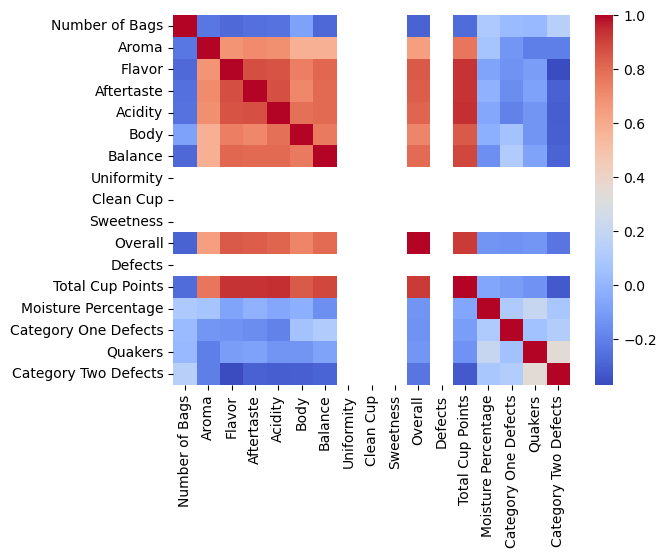

In [274]:
sns.heatmap(numberic_data.corr(), cmap="coolwarm")

After visualizing the correlation heatmap, the features that show a strong correlation with total_cup_points are Aroma, Flavour, Aftertaste, Body, Acidity, Balance, and Overall.

- Relationship Between Features and Coffee Quality

: To explore how sensory attributes such as aroma and flavor relate to the overall coffee quality score.

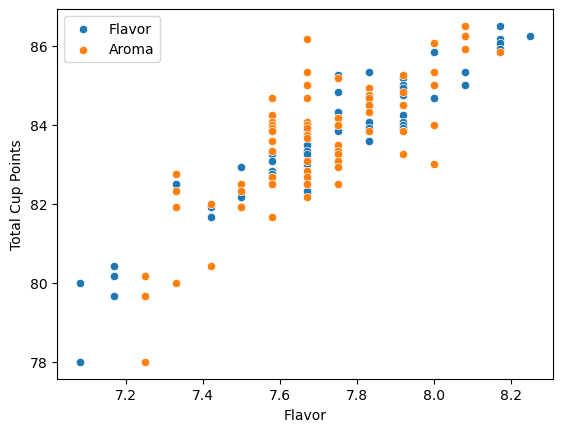

In [279]:
flavor = numberic_data['Flavor']
aroma = numberic_data['Aroma']
total_cup_points = numberic_data['Total Cup Points']
fig, ax = plt.subplots()
sns.scatterplot(x=flavor, y=total_cup_points, data=numberic_data, label= 'Flavor', ax=ax,)
sns.scatterplot(x=aroma, y=total_cup_points, data=numberic_data, label= 'Aroma', ax=ax,)


plt.show()

- Categorical Feature Analysis

: Analysis of Categorical Features (Country of Origin and Processing Method) with Coffee Quality.

Text(0.5, 0, 'Country')

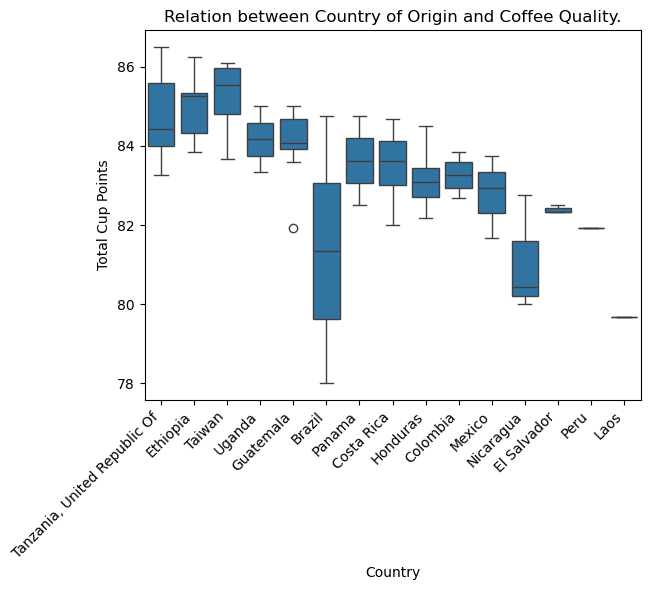

In [283]:
country = data['Country of Origin']
processing_method = data['Processing Method']
total_cup_points = numberic_data['Total Cup Points']
sns.boxplot(x=country, y=total_cup_points, data=data)
plt.title('Relation between Country of Origin and Coffee Quality.')
plt.xticks(rotation=45,ha='right')
plt.xlabel('Country')

Text(0.5, 0, 'Processing Method')

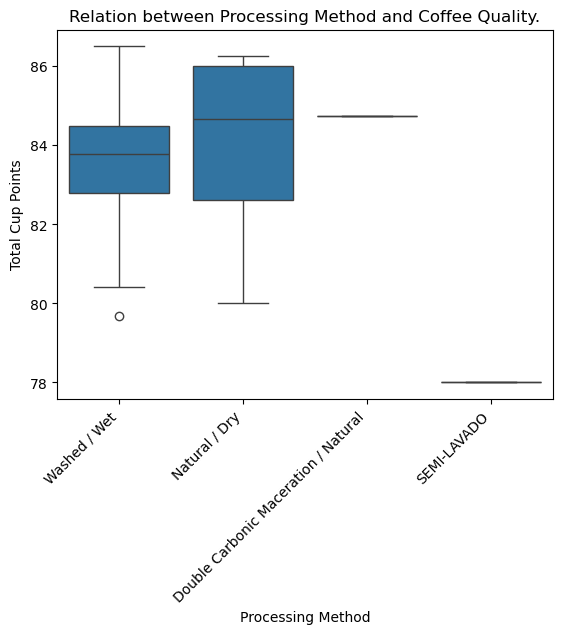

In [285]:
sns.boxplot(x=processing_method, y=total_cup_points, data=data)
plt.title('Relation between Processing Method and Coffee Quality.')
plt.xticks(rotation=45,ha='right')
plt.xlabel('Processing Method')

### Feature Preparation
- Categorical Feature converted into numerical format using one-hot encoding for machine learning.

In [288]:
categorical_feature = data[['Country of Origin','Processing Method']]
categorical_feature_enc = pd.get_dummies(categorical_feature, dtype='int')
categorical_feature_enc

,Country of Origin_Brazil,Country of Origin_Colombia,Country of Origin_Costa Rica,Country of Origin_El Salvador,Country of Origin_Ethiopia,Country of Origin_Guatemala,Country of Origin_Honduras,Country of Origin_Laos,Country of Origin_Mexico,Country of Origin_Nicaragua,Country of Origin_Panama,Country of Origin_Peru,Country of Origin_Taiwan,"Country of Origin_Tanzania, United Republic Of",Country of Origin_Uganda,Processing Method_Double Carbonic Maceration / Natural,Processing Method_Natural / Dry,Processing Method_SEMI-LAVADO,Processing Method_Washed / Wet
9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
10,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
13,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
17,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
18,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
201,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
203,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
204,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


- Concat data between numberic_data and categorical_feature_enc

In [291]:
data_concat = pd.concat([numberic_data,categorical_feature_enc] ,axis=1)
data_concat.head()

,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,...,Country of Origin_Nicaragua,Country of Origin_Panama,Country of Origin_Peru,Country of Origin_Taiwan,"Country of Origin_Tanzania, United Republic Of",Country of Origin_Uganda,Processing Method_Double Carbonic Maceration / Natural,Processing Method_Natural / Dry,Processing Method_SEMI-LAVADO,Processing Method_Washed / Wet
9,320,8.08,8.17,8.08,8.17,8.00,8.00,10.0,10.0,10.0,...,0,0,0,0,1,0,0,0,0,1
10,10,8.08,8.25,8.00,8.08,7.92,7.92,10.0,10.0,10.0,...,0,0,0,0,0,0,0,1,0,0
13,40,7.67,8.17,8.00,8.33,8.00,8.00,10.0,10.0,10.0,...,0,0,0,0,0,0,0,1,0,0
17,5,8.00,8.17,8.00,7.92,7.92,7.92,10.0,10.0,10.0,...,0,0,0,1,0,0,0,1,0,0
18,8,8.08,8.17,7.75,7.92,7.83,8.00,10.0,10.0,10.0,...,0,0,0,1,0,0,0,1,0,0


### Define feature and Target for train-test model

In [407]:
X = data_concat.drop(['Total Cup Points'], axis=1)
X = X.drop(['Overall'], axis=1)
X = X.drop(['Defects'], axis=1)
y = data_concat['Total Cup Points']

In [409]:
X.keys()

Index(['Number of Bags', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
       'Balance', 'Uniformity', 'Clean Cup', 'Sweetness',
       'Moisture Percentage', 'Category One Defects', 'Quakers',
       'Category Two Defects', 'Country of Origin_Brazil',
       'Country of Origin_Colombia', 'Country of Origin_Costa Rica',
       'Country of Origin_El Salvador', 'Country of Origin_Ethiopia',
       'Country of Origin_Guatemala', 'Country of Origin_Honduras',
       'Country of Origin_Laos', 'Country of Origin_Mexico',
       'Country of Origin_Nicaragua', 'Country of Origin_Panama',
       'Country of Origin_Peru', 'Country of Origin_Taiwan',
       'Country of Origin_Tanzania, United Republic Of',
       'Country of Origin_Uganda',
       'Processing Method_Double Carbonic Maceration / Natural',
       'Processing Method_Natural / Dry', 'Processing Method_SEMI-LAVADO',
       'Processing Method_Washed / Wet'],
      dtype='object')

### Train - Test Split 
- The dataset is split into training(80%) and testing(20%) sets to evaluate model performance.

In [411]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [413]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2 ,random_state=42)

### Model Evaluation

- Evaluated the model's prediction performance using Root Mean Squared Error (RMSE), which measures the difference between predicted and actual values.

In [417]:
model = RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

RandomForestRegressor was used because the model can evaluate the relationship between all features and the target variable by comparing their importance. Additionally, it can help reduce data dimensionality by identifying the most relevant features.

In [419]:
y_pred = model.predict(X_test)

In [421]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
rmse

0.3977037303607588

In [423]:
r2 = r2_score(y_test,y_pred)
r2

0.9018377657460674

In [425]:
feature_important = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_important
})

importance_df = importance_df.sort_values("importance", ascending=False)

<Axes: xlabel='importance', ylabel='feature'>

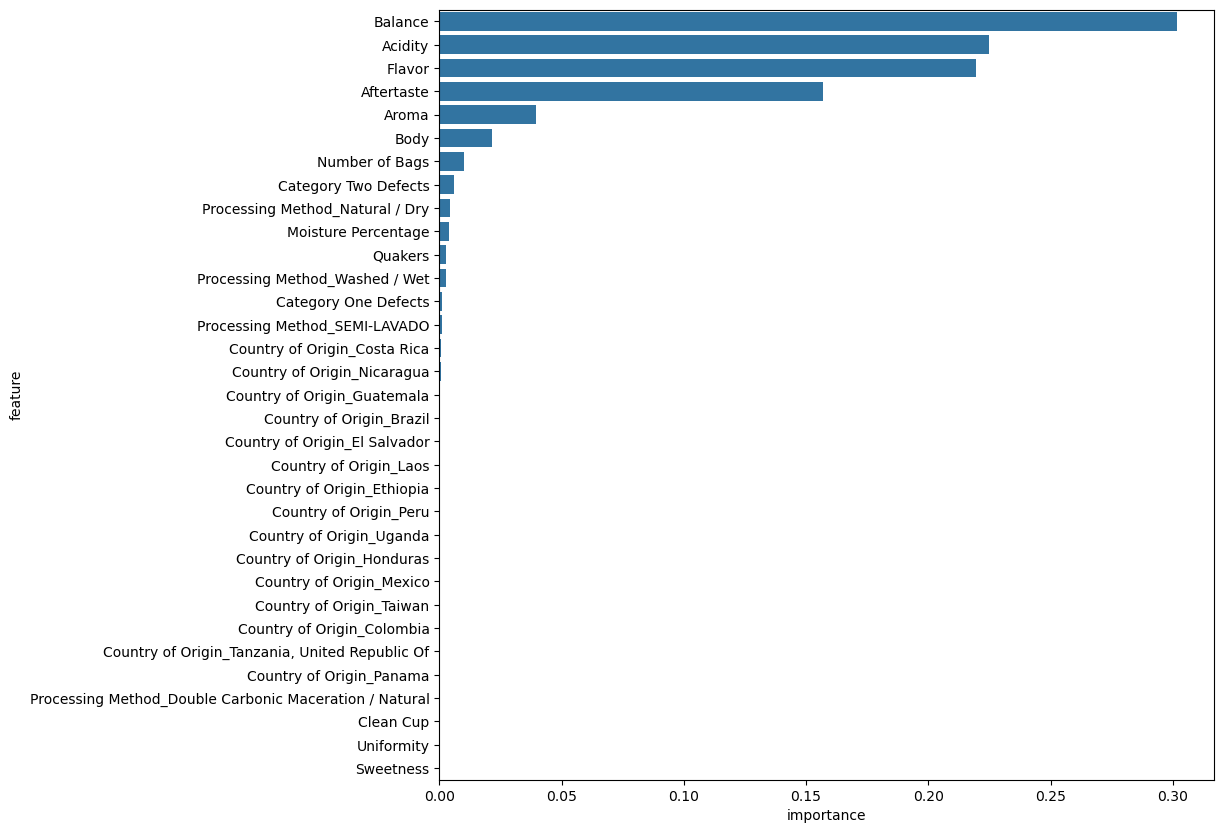

In [427]:
plt.figure(figsize=(10,10))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)


The feature balance, acidity, flavor, and afterteste appear to be the most influential attributes in determining the overall coffee quality score.

### Conclusion 

1.) The analysis shows that sensory attributes such as balance, acidity, flavor, and afterteste appear have strong relationships with coffee quality 
scores.

2.) The RandomForestRegressor model achieved an RMSE of 0.39 and an R-squared score of 0.90.